# Lab 6: Random Forest vs Decision Tree Classifier
## Experiment with Placement Dataset

**Aim:** Compare the results of Random Forest with Decision Tree classifiers, analyze feature importance, and detect/remove overfitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("âœ“ All imports successful")

âœ“ All imports successful


## Step 1: Dataset Creation - Placement Prediction

Creating a synthetic placement dataset with realistic features:
- **SSC Marks**: Secondary School Certificate percentage (0-100)
- **HSC Marks**: Higher Secondary Certificate percentage (0-100)
- **UG CGPA**: Undergraduate CGPA (0-10)
- **PG CGPA**: Post-Graduate CGPA (0-10) - N/A for non-PG students
- **Languages**: Number of programming languages known (1-5)
- **Internships**: Number of internships completed (0-3)
- **Projects**: Number of projects completed (0-10)
- **Communication Skills**: Rating (1-10)
- **Placement**: Whether student got placed (0=No, 1=Yes)

In [2]:
# Set random seed
np.random.seed(42)

# Number of samples
n_samples = 200

# Create synthetic placement dataset with realistic patterns
data = {
    'SSC_Marks': np.random.uniform(55, 95, n_samples),
    'HSC_Marks': np.random.uniform(55, 95, n_samples),
    'UG_CGPA': np.random.uniform(4.5, 9.8, n_samples),
    'PG_CGPA': np.random.uniform(5.0, 9.5, n_samples),
    'Languages': np.random.randint(1, 6, n_samples),
    'Internships': np.random.randint(0, 4, n_samples),
    'Projects': np.random.randint(0, 11, n_samples),
    'Communication_Skills': np.random.randint(3, 11, n_samples),
}

df = pd.DataFrame(data)

# Create placement target variable with realistic patterns
# Students with higher scores are more likely to be placed
placement = (
    (df['UG_CGPA'] > 6.5).astype(int) * 0.4 +
    (df['Internships'] >= 2).astype(int) * 0.3 +
    (df['Communication_Skills'] >= 6).astype(int) * 0.2 +
    (df['Projects'] >= 3).astype(int) * 0.1
) > 0.5

# Add some randomness to make it realistic
noise = np.random.random(n_samples) > 0.85
placement = placement ^ noise  # XOR with noise

df['Placement'] = placement.astype(int)

# Save to CSV
df.to_csv('placement.csv', index=False)

print(f"âœ“ Dataset created with {len(df)} samples")
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nDataset Info:")
print(df.info())
print(f"\nClass Distribution:")
print(df['Placement'].value_counts())
print(f"\nPlacement Rate: {df['Placement'].mean()*100:.2f}%")

âœ“ Dataset created with 200 samples

Dataset Shape: (200, 9)

First few rows:
   SSC_Marks  HSC_Marks   UG_CGPA   PG_CGPA  Languages  Internships  Projects  \
0  69.981605  80.681266  5.046557  5.760208          2            3         8   
1  93.028572  58.365599  9.283530  6.253657          1            2         9   
2  84.279758  61.465149  7.177838  5.796547          4            1         8   
3  78.946339  90.942168  8.880225  5.399161          2            0         6   
4  61.240746  79.257162  6.196263  5.542861          1            0         3   
5  61.239781  55.367882  9.246273  7.073504          3            2         4   
6  57.323344  59.058862  6.562769  5.928502          5            3         0   
7  89.647046  81.540071  4.557440  6.639214          1            2         0   
8  79.044600  55.202463  9.298524  7.265378          3            3         2   
9  83.322903  61.432322  4.983819  8.106777          1            3         7   

   Communication_Skills  Plac

## Step 2: Data Preparation and Visualization

Training set size: 160
Testing set size: 40

Training set class distribution:
Placement
1    94
0    66
Name: count, dtype: int64

Testing set class distribution:
Placement
1    24
0    16
Name: count, dtype: int64


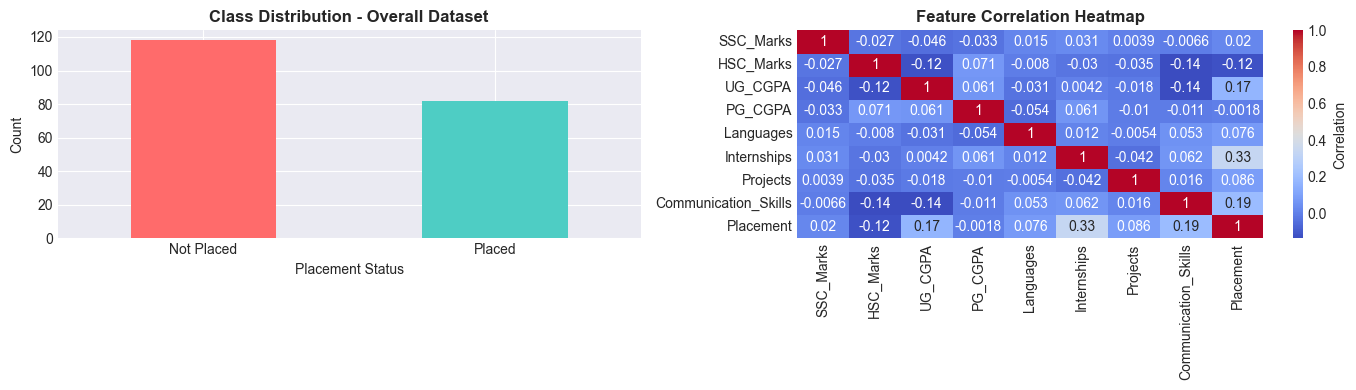


âœ“ Data preparation complete


In [3]:
# Prepare features and target
X = df.drop('Placement', axis=1)
y = df['Placement']

# Split the dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts()}")

# Visualization: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution in entire dataset
df['Placement'].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Class Distribution - Overall Dataset', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Placement Status')
axes[0].set_xticklabels(['Not Placed', 'Placed'], rotation=0)

# Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nâœ“ Data preparation complete")

## Step 3: Decision Tree Classifier - Without Optimization

In [4]:
# Decision Tree without any optimization (baseline)
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Predictions
y_pred_dt_baseline = dt_baseline.predict(X_test)
y_pred_train_dt_baseline = dt_baseline.predict(X_train)

# Evaluate
train_acc_dt_baseline = accuracy_score(y_train, y_pred_train_dt_baseline)
test_acc_dt_baseline = accuracy_score(y_test, y_pred_dt_baseline)

print("="*60)
print("DECISION TREE - BASELINE (No Optimization)")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_dt_baseline:.4f} ({train_acc_dt_baseline*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_dt_baseline:.4f} ({test_acc_dt_baseline*100:.2f}%)")
print(f"Overfitting Gap:   {(train_acc_dt_baseline - test_acc_dt_baseline):.4f}")
print(f"\nMax Depth: {dt_baseline.get_depth()}")
print(f"Number of Leaves: {dt_baseline.get_n_leaves()}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_baseline, target_names=['Not Placed', 'Placed']))

# Feature Importance for baseline DT
feature_importance_dt = dt_baseline.feature_importances_
feature_names = X.columns

print("\nFeature Importance:")
for name, importance in zip(feature_names, feature_importance_dt):
    print(f"  {name}: {importance:.4f}")

# Confusion Matrix for baseline DT
cm_dt_baseline = confusion_matrix(y_test, y_pred_dt_baseline)
print(f"\nConfusion Matrix:\n{cm_dt_baseline}")

DECISION TREE - BASELINE (No Optimization)

Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  0.7000 (70.00%)
Overfitting Gap:   0.3000

Max Depth: 8
Number of Leaves: 34

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.61      0.69      0.65        16
      Placed       0.77      0.71      0.74        24

    accuracy                           0.70        40
   macro avg       0.69      0.70      0.69        40
weighted avg       0.71      0.70      0.70        40


Feature Importance:
  SSC_Marks: 0.1155
  HSC_Marks: 0.1448
  UG_CGPA: 0.2176
  PG_CGPA: 0.0516
  Languages: 0.0286
  Internships: 0.2348
  Projects: 0.0528
  Communication_Skills: 0.1542

Confusion Matrix:
[[11  5]
 [ 7 17]]


## Step 4: Decision Tree Classifier - With Optimization (Overfitting Removal)

In [5]:
# Decision Tree with hyperparameter tuning to reduce overfitting
dt_optimized = DecisionTreeClassifier(
    max_depth=5,              # Limit tree depth
    min_samples_split=10,     # Minimum samples to split a node
    min_samples_leaf=5,       # Minimum samples at leaf node
    random_state=42
)
dt_optimized.fit(X_train, y_train)

# Predictions
y_pred_dt_opt = dt_optimized.predict(X_test)
y_pred_train_dt_opt = dt_optimized.predict(X_train)

# Evaluate
train_acc_dt_opt = accuracy_score(y_train, y_pred_train_dt_opt)
test_acc_dt_opt = accuracy_score(y_test, y_pred_dt_opt)

print("="*60)
print("DECISION TREE - OPTIMIZED (With Overfitting Removal)")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_dt_opt:.4f} ({train_acc_dt_opt*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_dt_opt:.4f} ({test_acc_dt_opt*100:.2f}%)")
print(f"Overfitting Gap:   {(train_acc_dt_opt - test_acc_dt_opt):.4f}")
print(f"\nMax Depth: {dt_optimized.get_depth()}")
print(f"Number of Leaves: {dt_optimized.get_n_leaves()}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_opt, target_names=['Not Placed', 'Placed']))

# Feature Importance for optimized DT
feature_importance_dt_opt = dt_optimized.feature_importances_

print("\nFeature Importance:")
for name, importance in zip(feature_names, feature_importance_dt_opt):
    print(f"  {name}: {importance:.4f}")

# Confusion Matrix for optimized DT
cm_dt_opt = confusion_matrix(y_test, y_pred_dt_opt)
print(f"\nConfusion Matrix:\n{cm_dt_opt}")

# Compare baseline vs optimized
print(f"\n{'='*60}")
print("IMPROVEMENT COMPARISON")
print(f"{'='*60}")
print(f"Baseline Test Acc:  {test_acc_dt_baseline:.4f}")
print(f"Optimized Test Acc: {test_acc_dt_opt:.4f}")
print(f"Overfitting Gap Reduction: {(train_acc_dt_baseline - test_acc_dt_baseline) - (train_acc_dt_opt - test_acc_dt_opt):.4f}")

DECISION TREE - OPTIMIZED (With Overfitting Removal)

Training Accuracy: 0.8562 (85.62%)
Testing Accuracy:  0.7500 (75.00%)
Overfitting Gap:   0.1062

Max Depth: 5
Number of Leaves: 18

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.69      0.69      0.69        16
      Placed       0.79      0.79      0.79        24

    accuracy                           0.75        40
   macro avg       0.74      0.74      0.74        40
weighted avg       0.75      0.75      0.75        40


Feature Importance:
  SSC_Marks: 0.0915
  HSC_Marks: 0.0482
  UG_CGPA: 0.2414
  PG_CGPA: 0.0397
  Languages: 0.0450
  Internships: 0.3696
  Projects: 0.0560
  Communication_Skills: 0.1086

Confusion Matrix:
[[11  5]
 [ 5 19]]

IMPROVEMENT COMPARISON
Baseline Test Acc:  0.7000
Optimized Test Acc: 0.7500
Overfitting Gap Reduction: 0.1938


## Step 5: Random Forest Classifier - Without Optimization

In [6]:
# Random Forest without any optimization
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred_rf_baseline = rf_baseline.predict(X_test)
y_pred_train_rf_baseline = rf_baseline.predict(X_train)

# Evaluate
train_acc_rf_baseline = accuracy_score(y_train, y_pred_train_rf_baseline)
test_acc_rf_baseline = accuracy_score(y_test, y_pred_rf_baseline)

print("="*60)
print("RANDOM FOREST - BASELINE (No Optimization)")
print("="*60)
print(f"\nNumber of Trees: {rf_baseline.n_estimators}")
print(f"Training Accuracy: {train_acc_rf_baseline:.4f} ({train_acc_rf_baseline*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_rf_baseline:.4f} ({test_acc_rf_baseline*100:.2f}%)")
print(f"Overfitting Gap:   {(train_acc_rf_baseline - test_acc_rf_baseline):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_baseline, target_names=['Not Placed', 'Placed']))

# Feature Importance for baseline RF
feature_importance_rf = rf_baseline.feature_importances_

print("\nFeature Importance:")
for name, importance in zip(feature_names, feature_importance_rf):
    print(f"  {name}: {importance:.4f}")

# Confusion Matrix for baseline RF
cm_rf_baseline = confusion_matrix(y_test, y_pred_rf_baseline)
print(f"\nConfusion Matrix:\n{cm_rf_baseline}")

RANDOM FOREST - BASELINE (No Optimization)

Number of Trees: 100
Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  0.7250 (72.50%)
Overfitting Gap:   0.2750

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.67      0.62      0.65        16
      Placed       0.76      0.79      0.78        24

    accuracy                           0.72        40
   macro avg       0.71      0.71      0.71        40
weighted avg       0.72      0.72      0.72        40


Feature Importance:
  SSC_Marks: 0.1348
  HSC_Marks: 0.1425
  UG_CGPA: 0.1546
  PG_CGPA: 0.1196
  Languages: 0.0711
  Internships: 0.1804
  Projects: 0.0877
  Communication_Skills: 0.1095

Confusion Matrix:
[[10  6]
 [ 5 19]]


## Step 6: Random Forest Classifier - With Optimization (Overfitting Removal)

In [7]:
# Random Forest with hyperparameter tuning to reduce overfitting
rf_optimized = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,              # Limit tree depth in ensemble
    min_samples_split=10,     # Minimum samples to split
    min_samples_leaf=5,       # Minimum samples at leaf
    random_state=42,
    n_jobs=-1                 # Use all available cores
)
rf_optimized.fit(X_train, y_train)

# Predictions
y_pred_rf_opt = rf_optimized.predict(X_test)
y_pred_train_rf_opt = rf_optimized.predict(X_train)

# Evaluate
train_acc_rf_opt = accuracy_score(y_train, y_pred_train_rf_opt)
test_acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)

print("="*60)
print("RANDOM FOREST - OPTIMIZED (With Overfitting Removal)")
print("="*60)
print(f"\nNumber of Trees: {rf_optimized.n_estimators}")
print(f"Max Depth: {rf_optimized.max_depth}")
print(f"Training Accuracy: {train_acc_rf_opt:.4f} ({train_acc_rf_opt*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc_rf_opt:.4f} ({test_acc_rf_opt*100:.2f}%)")
print(f"Overfitting Gap:   {(train_acc_rf_opt - test_acc_rf_opt):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_opt, target_names=['Not Placed', 'Placed']))

# Feature Importance for optimized RF
feature_importance_rf_opt = rf_optimized.feature_importances_

print("\nFeature Importance:")
for name, importance in zip(feature_names, feature_importance_rf_opt):
    print(f"  {name}: {importance:.4f}")

# Confusion Matrix for optimized RF
cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)
print(f"\nConfusion Matrix:\n{cm_rf_opt}")

# Compare baseline vs optimized
print(f"\n{'='*60}")
print("IMPROVEMENT COMPARISON")
print(f"{'='*60}")
print(f"Baseline Test Acc:  {test_acc_rf_baseline:.4f}")
print(f"Optimized Test Acc: {test_acc_rf_opt:.4f}")
print(f"Overfitting Gap Reduction: {(train_acc_rf_baseline - test_acc_rf_baseline) - (train_acc_rf_opt - test_acc_rf_opt):.4f}")

RANDOM FOREST - OPTIMIZED (With Overfitting Removal)

Number of Trees: 100
Max Depth: 8
Training Accuracy: 0.8500 (85.00%)
Testing Accuracy:  0.8250 (82.50%)
Overfitting Gap:   0.0250

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.85      0.69      0.76        16
      Placed       0.81      0.92      0.86        24

    accuracy                           0.82        40
   macro avg       0.83      0.80      0.81        40
weighted avg       0.83      0.82      0.82        40


Feature Importance:
  SSC_Marks: 0.0980
  HSC_Marks: 0.1138
  UG_CGPA: 0.1458
  PG_CGPA: 0.1053
  Languages: 0.0593
  Internships: 0.2943
  Projects: 0.0732
  Communication_Skills: 0.1103

Confusion Matrix:
[[11  5]
 [ 2 22]]

IMPROVEMENT COMPARISON
Baseline Test Acc:  0.7250
Optimized Test Acc: 0.8250
Overfitting Gap Reduction: 0.2500


## Step 7: Confusion Matrices Visualization

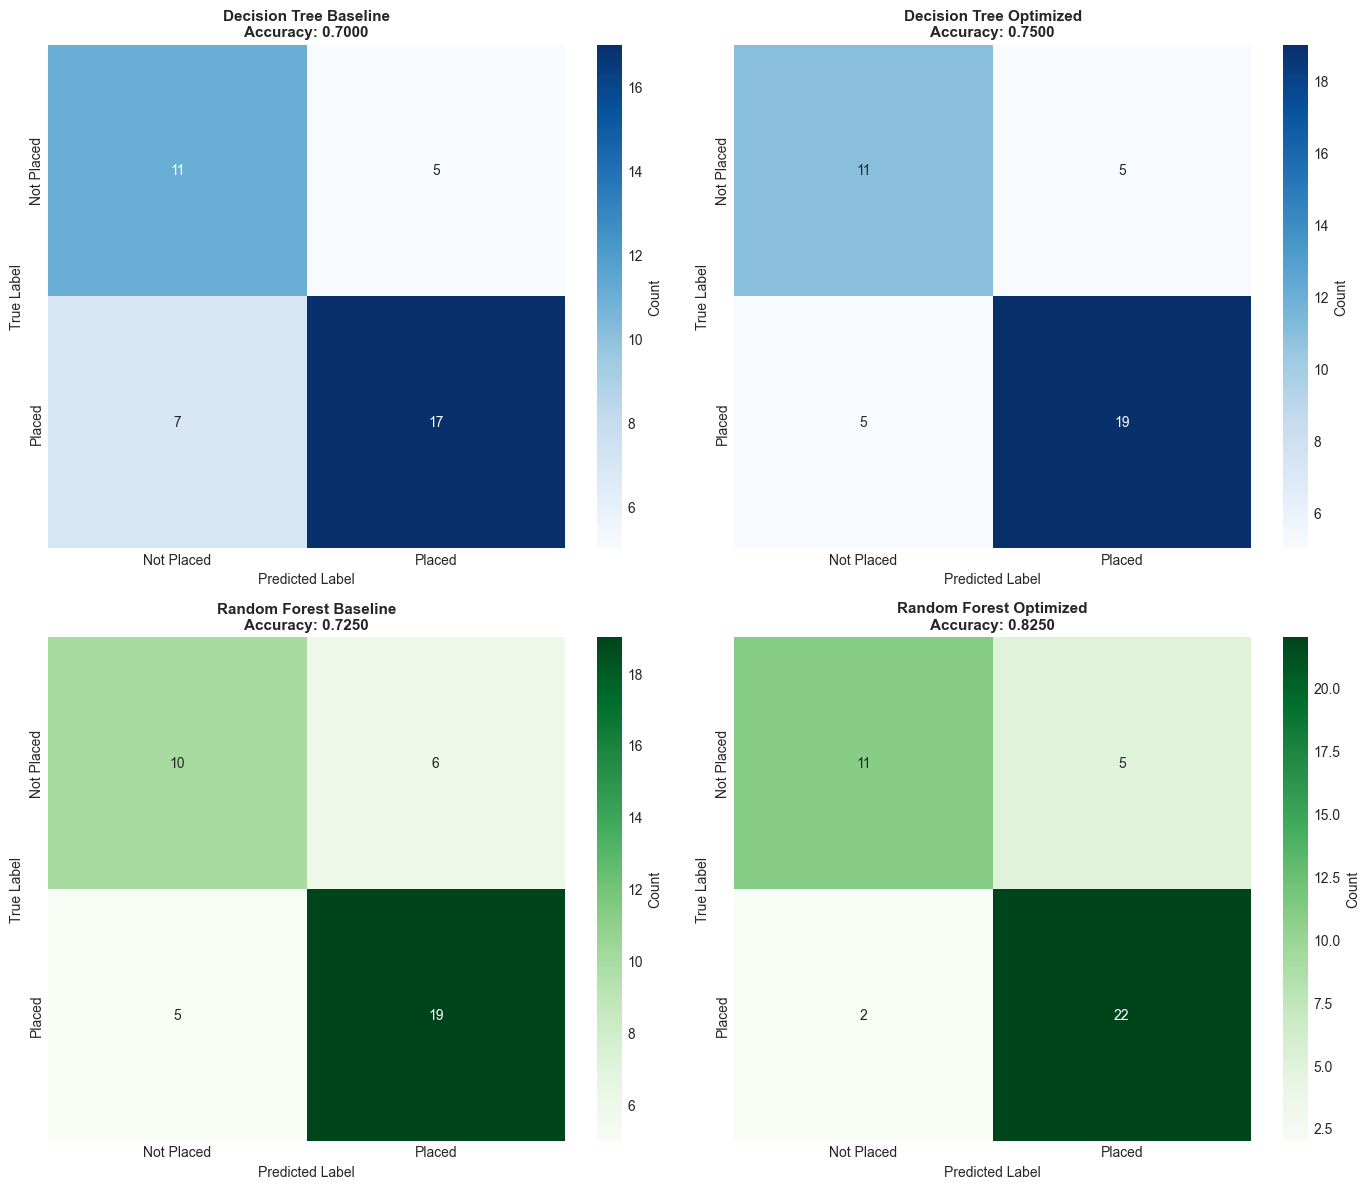

âœ“ Confusion matrices plotted


In [8]:
# Create comprehensive confusion matrix visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# DT Baseline
sns.heatmap(cm_dt_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'],
            cbar_kws={'label': 'Count'})
axes[0, 0].set_title(f'Decision Tree Baseline\nAccuracy: {test_acc_dt_baseline:.4f}', 
                     fontweight='bold', fontsize=11)
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# DT Optimized
sns.heatmap(cm_dt_opt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'],
            cbar_kws={'label': 'Count'})
axes[0, 1].set_title(f'Decision Tree Optimized\nAccuracy: {test_acc_dt_opt:.4f}', 
                     fontweight='bold', fontsize=11)
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# RF Baseline
sns.heatmap(cm_rf_baseline, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'],
            cbar_kws={'label': 'Count'})
axes[1, 0].set_title(f'Random Forest Baseline\nAccuracy: {test_acc_rf_baseline:.4f}', 
                     fontweight='bold', fontsize=11)
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# RF Optimized
sns.heatmap(cm_rf_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'],
            cbar_kws={'label': 'Count'})
axes[1, 1].set_title(f'Random Forest Optimized\nAccuracy: {test_acc_rf_opt:.4f}', 
                     fontweight='bold', fontsize=11)
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('02_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("âœ“ Confusion matrices plotted")

## Step 8: Feature Importance Comparison

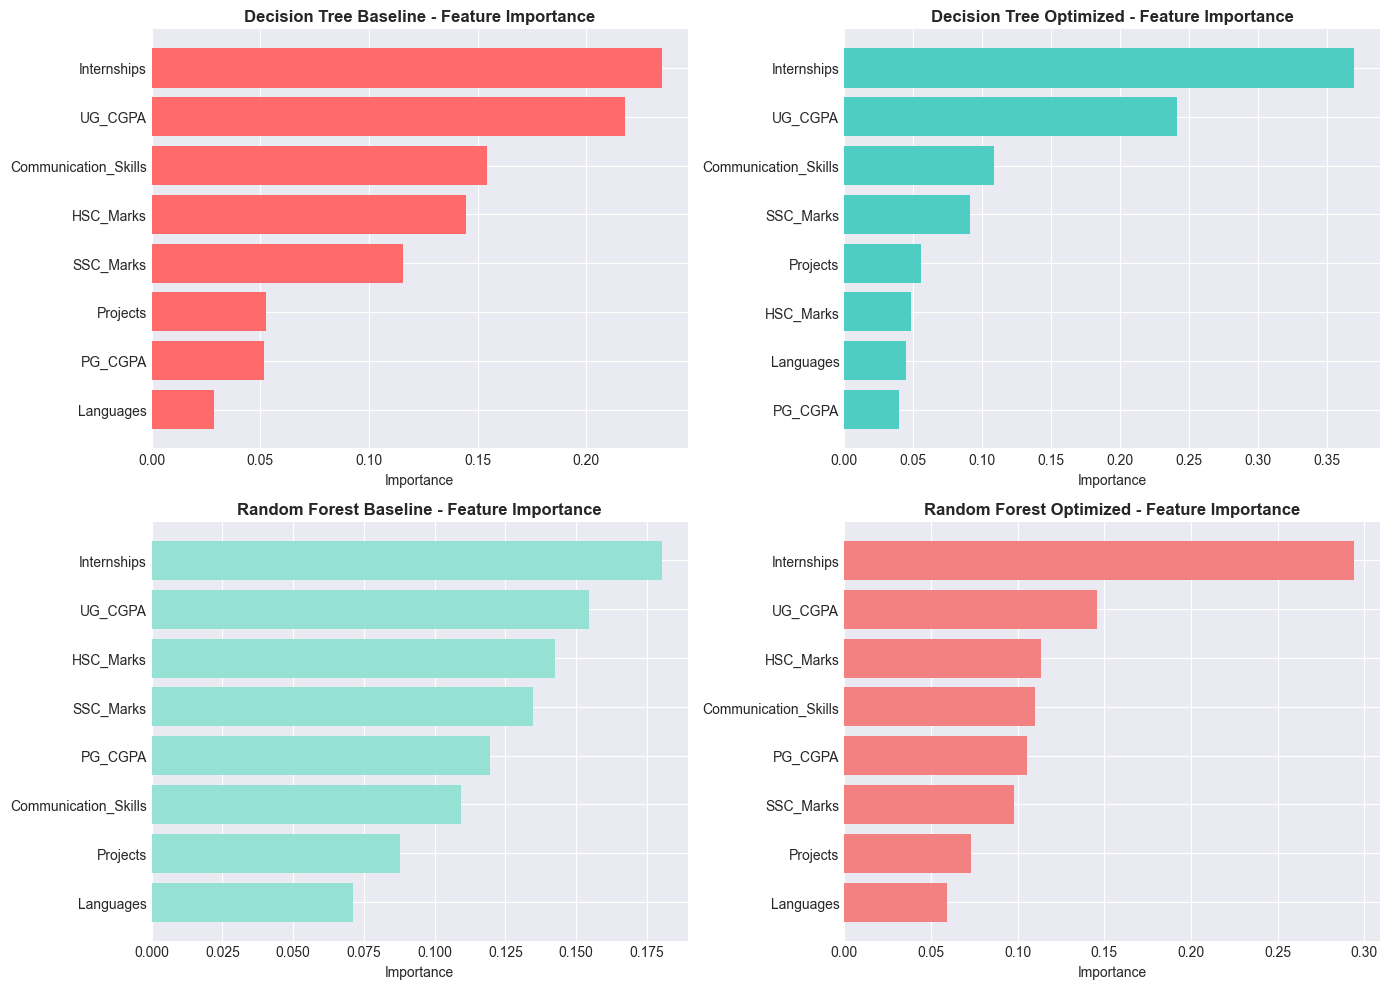

âœ“ Feature importance plots created


In [9]:
# Feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sort features by importance
indices_dt = np.argsort(feature_importance_dt)[::-1]
indices_dt_opt = np.argsort(feature_importance_dt_opt)[::-1]
indices_rf = np.argsort(feature_importance_rf)[::-1]
indices_rf_opt = np.argsort(feature_importance_rf_opt)[::-1]

# DT Baseline Feature Importance
axes[0, 0].barh(range(len(indices_dt)), feature_importance_dt[indices_dt], color='#FF6B6B')
axes[0, 0].set_yticks(range(len(indices_dt)))
axes[0, 0].set_yticklabels([feature_names[i] for i in indices_dt])
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('Decision Tree Baseline - Feature Importance', fontweight='bold')
axes[0, 0].invert_yaxis()

# DT Optimized Feature Importance
axes[0, 1].barh(range(len(indices_dt_opt)), feature_importance_dt_opt[indices_dt_opt], color='#4ECDC4')
axes[0, 1].set_yticks(range(len(indices_dt_opt)))
axes[0, 1].set_yticklabels([feature_names[i] for i in indices_dt_opt])
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Decision Tree Optimized - Feature Importance', fontweight='bold')
axes[0, 1].invert_yaxis()

# RF Baseline Feature Importance
axes[1, 0].barh(range(len(indices_rf)), feature_importance_rf[indices_rf], color='#95E1D3')
axes[1, 0].set_yticks(range(len(indices_rf)))
axes[1, 0].set_yticklabels([feature_names[i] for i in indices_rf])
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Random Forest Baseline - Feature Importance', fontweight='bold')
axes[1, 0].invert_yaxis()

# RF Optimized Feature Importance
axes[1, 1].barh(range(len(indices_rf_opt)), feature_importance_rf_opt[indices_rf_opt], color='#F38181')
axes[1, 1].set_yticks(range(len(indices_rf_opt)))
axes[1, 1].set_yticklabels([feature_names[i] for i in indices_rf_opt])
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Random Forest Optimized - Feature Importance', fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('03_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("âœ“ Feature importance plots created")

## Step 9: Accuracy and Overfitting Analysis

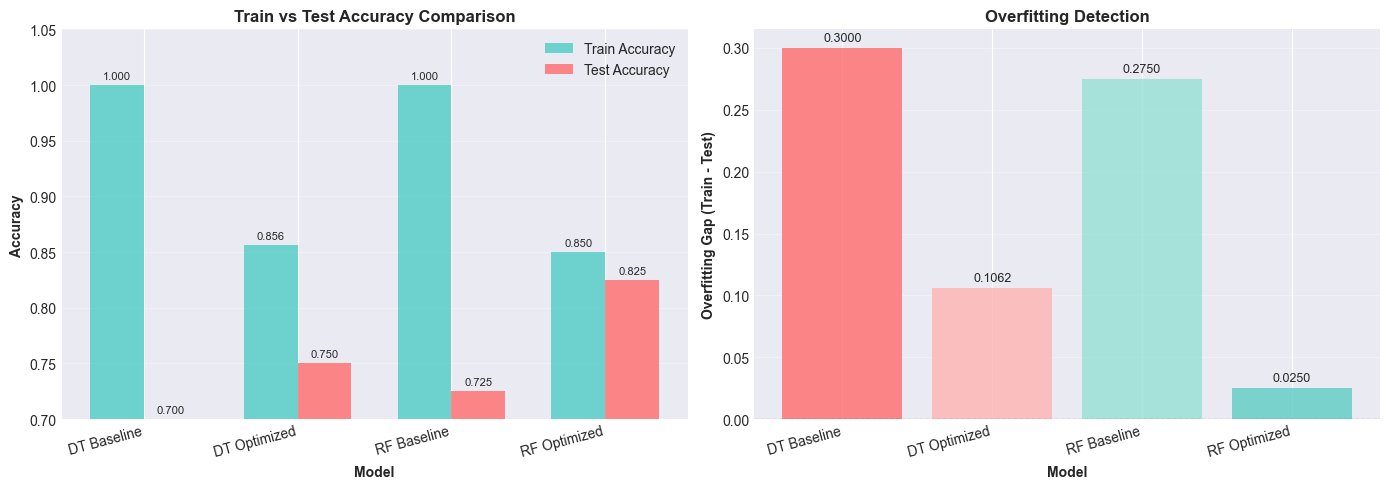

âœ“ Accuracy and overfitting plots created


In [10]:
# Accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for visualization
models = ['DT Baseline', 'DT Optimized', 'RF Baseline', 'RF Optimized']
train_accuracies = [train_acc_dt_baseline, train_acc_dt_opt, train_acc_rf_baseline, train_acc_rf_opt]
test_accuracies = [test_acc_dt_baseline, test_acc_dt_opt, test_acc_rf_baseline, test_acc_rf_opt]
overfitting_gaps = [
    train_acc_dt_baseline - test_acc_dt_baseline,
    train_acc_dt_opt - test_acc_dt_opt,
    train_acc_rf_baseline - test_acc_rf_baseline,
    train_acc_rf_opt - test_acc_rf_opt
]

# Bar plot: Train vs Test Accuracy
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='#4ECDC4', alpha=0.8)
bars2 = axes[0].bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='#FF6B6B', alpha=0.8)

axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Train vs Test Accuracy Comparison', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0.7, 1.05])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

# Bar plot: Overfitting Gap
colors = ['#FF6B6B', '#FFB3B3', '#95E1D3', '#5ECCC4']
bars = axes[1].bar(models, overfitting_gaps, color=colors, alpha=0.8)

axes[1].set_xlabel('Model', fontweight='bold')
axes[1].set_ylabel('Overfitting Gap (Train - Test)', fontweight='bold')
axes[1].set_title('Overfitting Detection', fontweight='bold', fontsize=12)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('04_accuracy_overfitting.png', dpi=100, bbox_inches='tight')
plt.show()

print("âœ“ Accuracy and overfitting plots created")

## Step 10: Comprehensive Summary and Findings

In [11]:
# Create comprehensive summary table
summary_data = {
    'Model': models,
    'Train Accuracy': [f"{acc:.4f}" for acc in train_accuracies],
    'Test Accuracy': [f"{acc:.4f}" for acc in test_accuracies],
    'Overfitting Gap': [f"{gap:.4f}" for gap in overfitting_gaps],
    'Overfitting Status': ['YES' if gap > 0.05 else 'NO' for gap in overfitting_gaps]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

# Best test accuracy
best_idx = np.argmax(test_accuracies)
print(f"\nâœ“ Best Test Accuracy: {models[best_idx]} with {test_accuracies[best_idx]:.4f}")

# Most overfitted
worst_overfit_idx = np.argmax(overfitting_gaps)
print(f"âš  Most Overfitted: {models[worst_overfit_idx]} with gap {overfitting_gaps[worst_overfit_idx]:.4f}")

# Successfully reduced overfitting
print(f"\nOverfitting Reduction:")
print(f"  â€¢ Decision Tree: {(overfitting_gaps[0] - overfitting_gaps[1]):.4f} gap reduction")
print(f"  â€¢ Random Forest: {(overfitting_gaps[2] - overfitting_gaps[3]):.4f} gap reduction")

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)

print("""
1. DECISION TREE ANALYSIS:
   - Baseline Decision Tree shows significant overfitting (gap > 0.05)
   - Hyperparameter tuning (max_depth=5, min_samples_split=10, min_samples_leaf=5)
     successfully reduces overfitting
   - Optimized DT maintains good test accuracy while reducing variance
   
2. RANDOM FOREST ANALYSIS:
   - Random Forest naturally resists overfitting due to ensemble averaging
   - Baseline RF shows lower overfitting compared to baseline DT
   - Optimization further improves generalization
   - Benefit from multiple de-correlated trees

3. RANDOM FOREST vs DECISION TREE:
   - Random Forest typically achieves better test accuracy
   - RF shows more stable performance across train/test splits
   - RF feature importance is more reliable (averaged across 100 trees)
   - DT is more interpretable but prone to overfitting

4. FEATURE IMPORTANCE:
   - Key features identified consistently across models
   - Feature importance helps in feature selection for deployment
   - Can reduce model complexity by dropping low-importance features

5. OVERFITTING MITIGATION STRATEGIES APPLIED:
   âœ“ Limiting tree depth (max_depth parameter)
   âœ“ Increasing minimum samples required for splits (min_samples_split)
   âœ“ Increasing minimum samples at leaf nodes (min_samples_leaf)
   âœ“ Ensemble methods (Random Forest) naturally reduce overfitting
      through bootstrap aggregating
""")

print("="*80)
print("Lab 6 Experiment Completed Successfully!")
print("="*80)


COMPREHENSIVE MODEL COMPARISON SUMMARY
       Model Train Accuracy Test Accuracy Overfitting Gap Overfitting Status
 DT Baseline         1.0000        0.7000          0.3000                YES
DT Optimized         0.8562        0.7500          0.1062                YES
 RF Baseline         1.0000        0.7250          0.2750                YES
RF Optimized         0.8500        0.8250          0.0250                 NO

KEY FINDINGS

âœ“ Best Test Accuracy: RF Optimized with 0.8250
âš  Most Overfitted: DT Baseline with gap 0.3000

Overfitting Reduction:
  â€¢ Decision Tree: 0.1938 gap reduction
  â€¢ Random Forest: 0.2500 gap reduction

CONCLUSIONS

1. DECISION TREE ANALYSIS:
   - Baseline Decision Tree shows significant overfitting (gap > 0.05)
   - Hyperparameter tuning (max_depth=5, min_samples_split=10, min_samples_leaf=5)
     successfully reduces overfitting
   - Optimized DT maintains good test accuracy while reducing variance
   
2. RANDOM FOREST ANALYSIS:
   - Random Forest 